# Iris Dataset

Importing the required datasets

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

Importing Iris Data Frame from Sklearn

In [113]:
from sklearn import datasets
iris=datasets.load_iris()

Sorting dataset to categories

In [114]:
# Load iris into a dataframe and set the field names
df = pd.DataFrame(iris['data'], columns=iris['feature_names'])
>>> print (iris.target_names)
>>> ['setosa' 'versicolor' 'virginica']
>>> print (iris.target)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Describing mean, median, standard deviation etc.

In [115]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Histograms for septal length, septal width, petal length and petal width

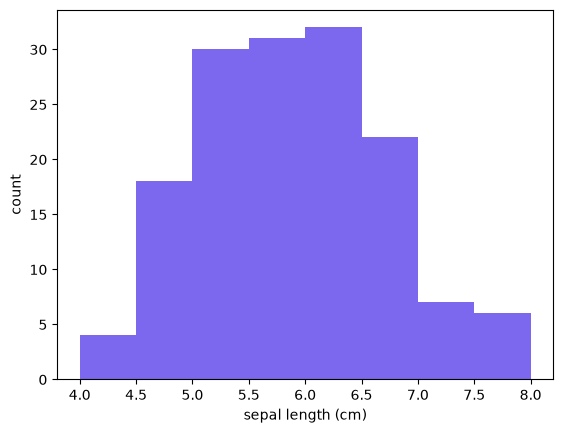

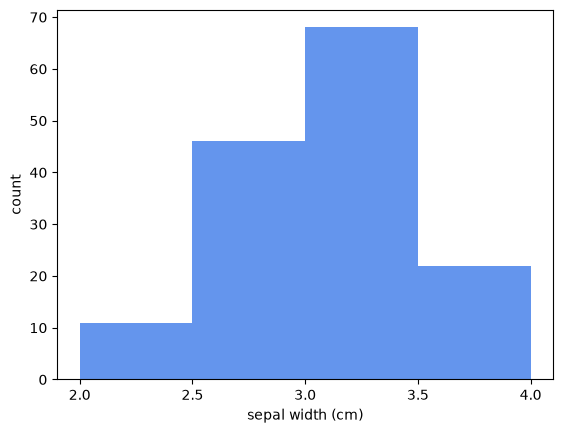

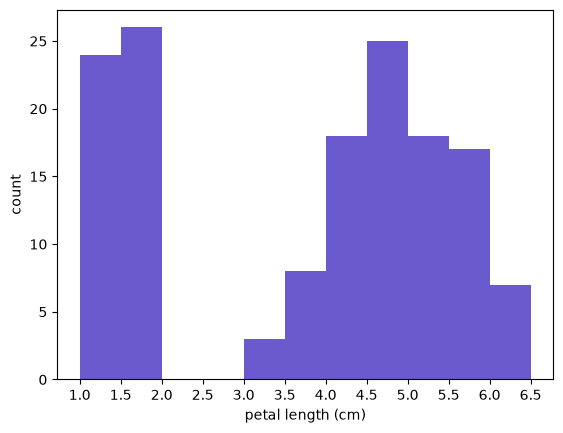

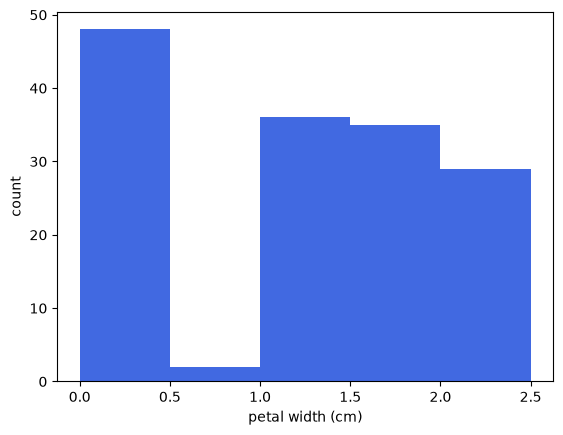

In [116]:
sl="sepal length (cm)"
sw="sepal width (cm)"
pl="petal length (cm)"
pw="petal width (cm)"
dict_binsx={sl:np.arange(4,8.5,0.5),sw:np.arange(2,4.5,0.5),pl:np.arange(1,7,0.5),pw:np.arange(0,3,0.5)}
dict_color={sl:"MediumSlateBlue", sw:"CornflowerBlue", pl:"SlateBlue", pw:"RoyalBlue"}
for col in [sl,sw,pl,pw]:
    plt.hist(df[col],color=dict_color[col],bins=dict_binsx[col])
    plt.xticks(dict_binsx[col])
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

Bar chart for number of flowers in each iris species

<function matplotlib.pyplot.show(close=None, block=None)>

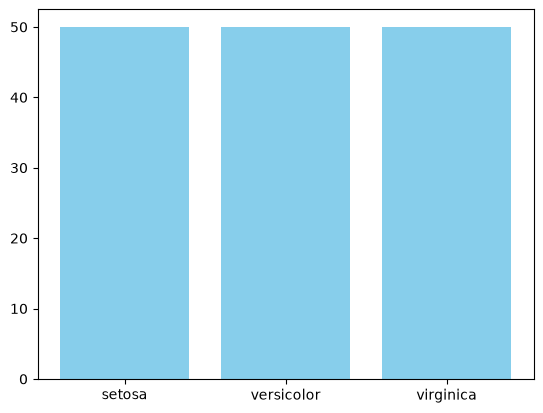

In [117]:
i=df["species"].value_counts()
binsx=i.index.values
plt.bar(i.index, i.values, color="SkyBlue")
plt.xticks(binsx)
plt.show


Scatter plot of septal length vs septal width of the different iris species

Converting dataframe into a grid for the heatmap

In [118]:
# To turn the value counts into a grid:
df_grid = a.reset_index().pivot(index=sl, columns=sw, values='count')
# Change missing values to zeros:
df_grid = df_grid.fillna(0.0)
df_grid

NameError: name 'a' is not defined

Histogram showing septal width vs septal length

<function matplotlib.pyplot.show(close=None, block=None)>

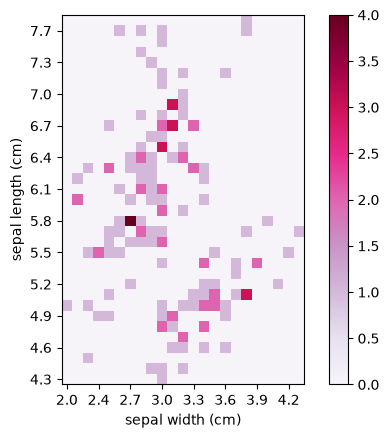

In [ ]:
gr=plt.imshow(df_grid, cmap="PuRd", origin='lower')
plt.xlabel(sw)
plt.ylabel(sl)
plt.xticks(range(len(df_grid.columns))[::3], df_grid.columns[::3])
plt.yticks(range(len(df_grid.index))[::3], df_grid.index[::3])
plt.colorbar(gr)
plt.show

Defining the line for a line chart

In [ ]:
X = df_set[sl]
y = df_set[sw]
X = sm.add_constant(X)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())
b = res.params

                            OLS Regression Results                            
Dep. Variable:       sepal width (cm)   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     58.99
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           6.71e-10
Time:                        14:06:23   Log-Likelihood:                -1.9002
No. Observations:                  50   AIC:                             7.800
Df Residuals:                      48   BIC:                             11.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.5694      0.52

Caluculations for the line

In [ ]:
c = s['const']
m = s[sl]

print(c)
print(m)

-0.569432673039649
0.7985283006471534


Scatter chart vs line of regression- septal length vs septal width 

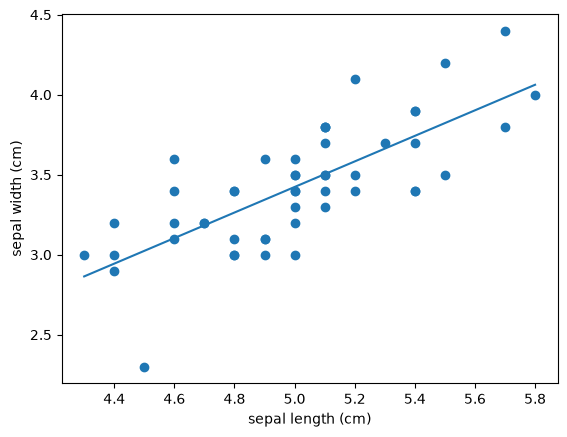

In [ ]:
xmin = df_set[sl].min()
xmax = df_set[sl].max()
line_ymin = m*xmin + c
line_ymax = m*xmax + c
plt.scatter(df_set[sl], df_set[sw])
plt.plot([xmin, xmax], [line_ymin, line_ymax])
plt.xlabel(sl)
plt.ylabel(sw)
plt.show()

Line calculation+Line of regression for virginica- sepal length vs width 

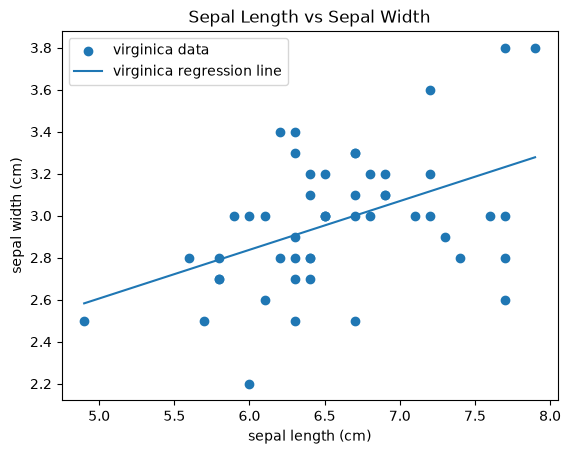

In [ ]:
species_all = ['setosa', 'versicolor', 'virginica']

for species in species_all:
    df_species = df[df['species'] == species]
    X = df_species[sl]
    y = df_species[sw]
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm)
    results = model.fit()
    c, m = results.params
    xmin = X.min()
    xmax = X.max()
plt.scatter(X, y, label=f"{species} data")
plt.plot([xmin, xmax], [m*xmin + c, m*xmax + c], label=f"{species} regression line")
plt.xlabel(sl)
plt.ylabel(sw)
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.show()

Sepal length vs width scatter chart+line of regression for all three species

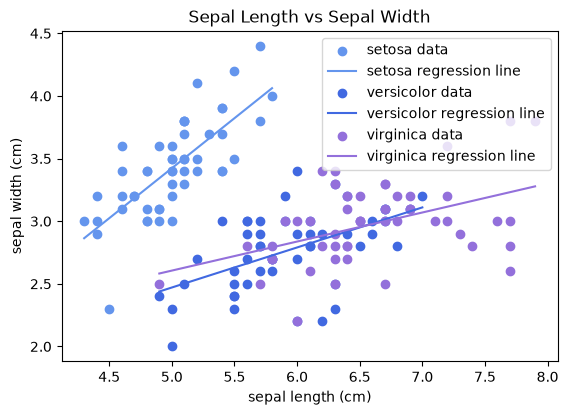

In [ ]:
dict_col = {"setosa": "CornflowerBlue","versicolor": "RoyalBlue","virginica": "MediumPurple"}
for species in species_all:
    df_species = df[df['species'] == species]
    X = df_species[sl]
    y = df_species[sw]
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm)
    results = model.fit()
    c, m = results.params
    xmin = X.min()
    xmax = X.max()
    plt.scatter(X, y, label=f"{species} data",color=dict_col[species])
    plt.plot([xmin, xmax], [m*xmin + c, m*xmax + c], label=f"{species} regression line",color=dict_col[species])
plt.xlabel(sl)
plt.ylabel(sw)
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

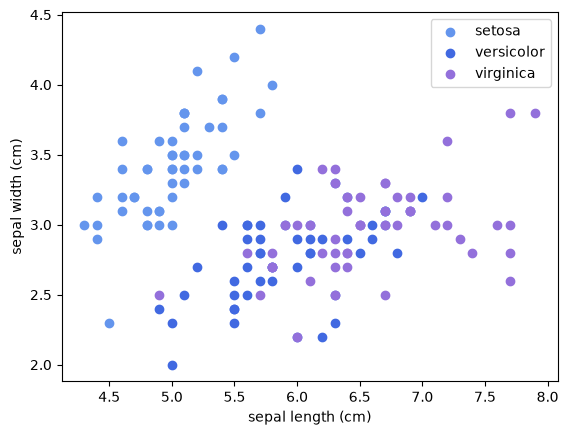

In [ ]:
species = ["setosa", "versicolor", "virginica"]
for sp in species:
    mask = df["species"] == sp
    df_sp = df.loc[mask]
    plt.scatter(df_sp[sl], df_sp[sw], label=sp,color=dict_col[sp])

plt.xlabel(sl)
plt.ylabel(sw)
plt.legend()
plt.show()

Longer method to do the same thing!

<function matplotlib.pyplot.show(close=None, block=None)>

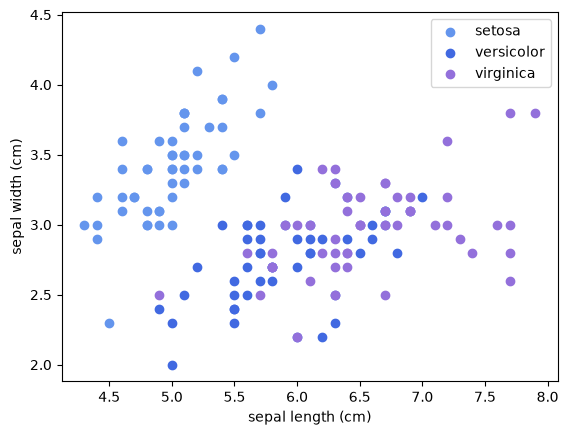

In [ ]:
mask=df["species"]=='setosa'
dfset=df.loc[mask]
dfvirver=df.loc[~mask]
plt.scatter(dfset[sl],dfset[sw],label="setosa",color="CornflowerBlue")
mask=df["species"]=='versicolor'
dfver=df.loc[mask]
dfsetvir=df.loc[~mask]
plt.scatter(dfver[sl],dfver[sw],label="versicolor",color="RoyalBlue")
mask=df["species"]=='virginica'
dfvir=df.loc[mask]
dfsetver=df.loc[~mask]
plt.scatter(dfvir[sl],dfvir[sw],label="virginica",color="MediumPurple")
plt.xlabel(sl)
plt.ylabel(sw) 
plt.legend() 
plt.show


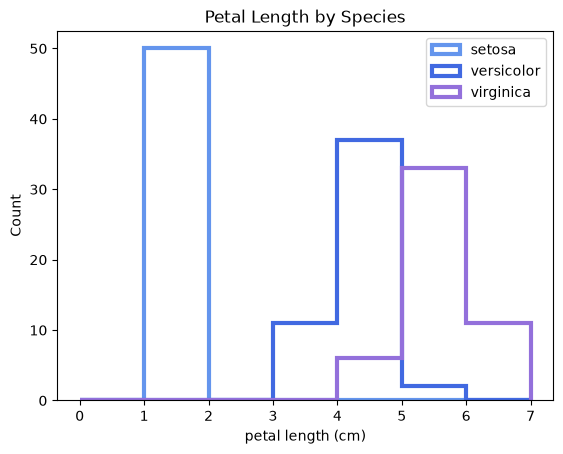

In [136]:
binsx=np.arange(0,8,1)
for sp in species:
    mask = df["species"] == sp
    df_sp = df.loc[mask]
    plt.hist(df_sp[pl],color=dict_col[sp],label=sp,bins=binsx,histtype="step",linewidth=3)
plt.xlabel(pl)
plt.ylabel("Count")
plt.xticks(binsx)
plt.title("Petal Length by Species")
plt.legend()
plt.show()

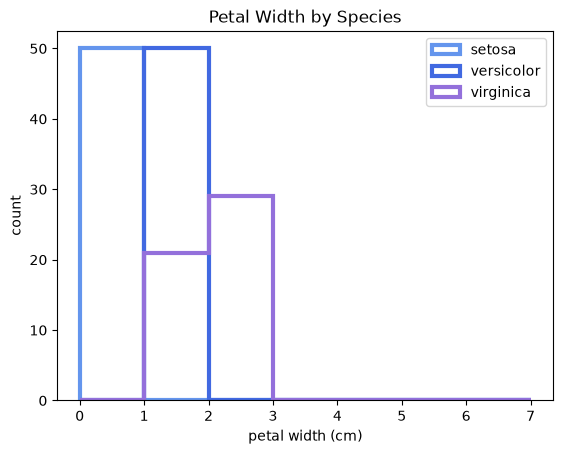

In [139]:
for sp in species:
    mask=df["species"]==sp
    df_sp=df.loc[mask]
    plt.hist(df_sp[pw],color=dict_col[sp],bins=binsx,label=sp,histtype="step",linewidth=3)
plt.xlabel(pw)
plt.ylabel("count")
plt.xticks(binsx)
plt.title("Petal Width by Species")
plt.legend()
plt.show()